# Week 3: Event Generation Analysis

Exploratory analysis of the synthetic event dataset generated during Week 3.

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/processed/features.csv")
df.head()


,event_id,user_id,event_type,timestamp,hour_of_day,day_of_week,is_weekend,is_anomalous,anomaly_type,ip_address,...,unique_ips_last_10_logins,unique_countries_last_10_logins,unique_devices_last_10_logins,rolling_failed_attempts_5,roll_5_deposit_sum,withdrawal_to_deposit_ratio,trade_vol_zscore,pnl_zscore,amount_zscore,session_duration_zscore
0,EVT_304595,USER_0000,trade,2024-01-01 01:04:36,1,0,0,1,wash_trader,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.565431,-0.423405,0.000000,0.0
1,EVT_637273,USER_0000,trade,2024-01-01 16:01:51,16,0,0,1,wash_trader,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.582884,-0.484037,0.000000,0.0
2,EVT_749975,USER_0000,trade,2024-01-02 14:09:59,14,1,0,1,wash_trader,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.531557,-0.562527,0.000000,0.0
3,EVT_969821,USER_0000,login,2024-01-03 04:47:38,4,2,0,1,wash_trader,172.16.4.1,...,1.0,1.0,1.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0
4,EVT_299345,USER_0000,withdrawal,2024-01-04 08:32:44,8,3,0,1,wash_trader,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,-1.180471,0.0


## Dataset Overview

In [2]:

print(df.shape)
print(df.info())
print(df.describe(include='all').T)


(50000, 58)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 58 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   event_id                         50000 non-null  object 
 1   user_id                          50000 non-null  object 
 2   event_type                       50000 non-null  object 
 3   timestamp                        50000 non-null  object 
 4   hour_of_day                      50000 non-null  int64  
 5   day_of_week                      50000 non-null  int64  
 6   is_weekend                       50000 non-null  int64  
 7   is_anomalous                     50000 non-null  int64  
 8   anomaly_type                     50000 non-null  object 
 9   ip_address                       11033 non-null  object 
 10  country                          11032 non-null  object 
 11  device                           17060 non-null  object 
 12  login_

## Beginner Task 1: Event Distribution

event_type
trade         17446
login         11014
deposit        7565
session        6021
withdrawal     5115
kyc_change     2839
Name: count, dtype: int64

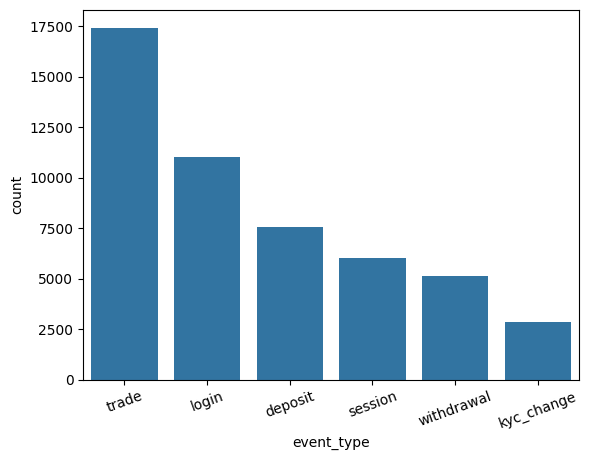

In [3]:

event_counts=df["event_type"].value_counts()
display(event_counts)
sns.countplot(data=df,x="event_type",order=event_counts.index)
plt.xticks(rotation=20)
plt.show()



### Observations
- Trade events are the most frequent, followed by logins.
- KYC updates are the least frequent.
- The distribution reflects realistic trading platform activity.


## Beginner Task 2: Total Anomalous Users

In [4]:

print("Unique users:",df["user_id"].nunique())
print("Anomalous users:",df[df["is_anomalous"]==1]["user_id"].nunique())


Unique users: 500
Anomalous users: 25


## Beginner Task 3: Most Common Countries

country
US    1456
CN    1361
RU    1277
NG    1209
IN    1113
AE    1096
UK     943
BR     939
SG     898
DE     740
Name: count, dtype: int64

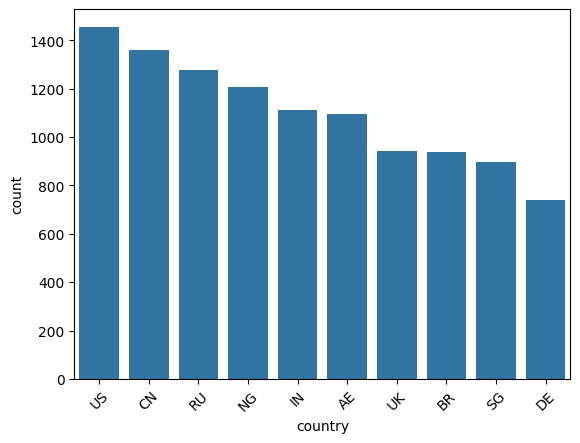

In [5]:

countries=df["country"].value_counts()
display(countries)
sns.countplot(data=df,x="country",order=countries.index)
plt.xticks(rotation=45)
plt.show()


## Beginner Task 4: Most Common Devices

device
ios_app          3690
android_app      3480
safari_mac       3462
chrome_win       3260
firefox_linux    3168
Name: count, dtype: int64

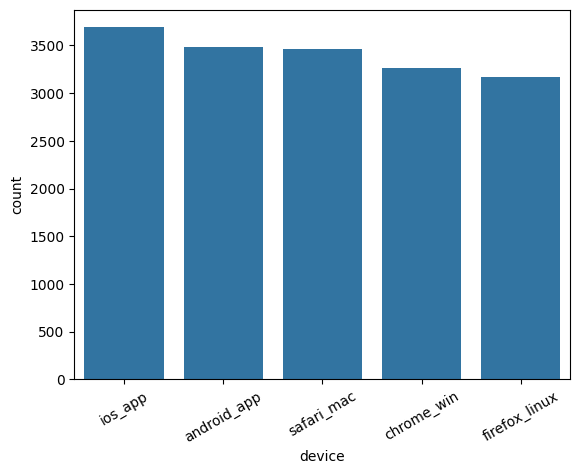

In [6]:

devices=df["device"].value_counts()
display(devices)
sns.countplot(data=df,x="device",order=devices.index)
plt.xticks(rotation=30)
plt.show()


## Intermediate Task 1: Trade Volume Comparison

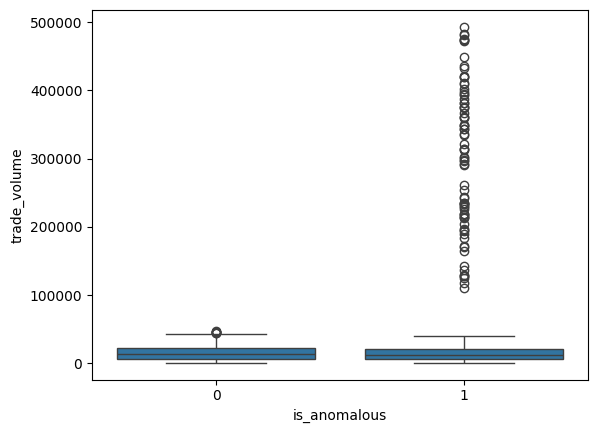

,count,mean,std,min,25%,50%,75%,max
is_anomalous,,,,,,,,
0,16529.0,14696.256498,9292.928339,585.33,6426.81,13742.09,21548.50,47889.61
1,917.0,37622.861854,87822.807440,659.77,5466.19,11999.12,20807.49,493382.76


In [7]:

trade=df[df.event_type=="trade"]
sns.boxplot(data=trade,x="is_anomalous",y="trade_volume")
plt.show()
display(trade.groupby("is_anomalous")["trade_volume"].describe())



### Observations
- Anomalous trades generally have higher trade volumes and greater variability.
- Normal trades remain concentrated around typical user behaviour.


## Intermediate Task 2: Login Behaviour

,failed_attempts
is_anomalous,
0,0.04953
1,0.13255


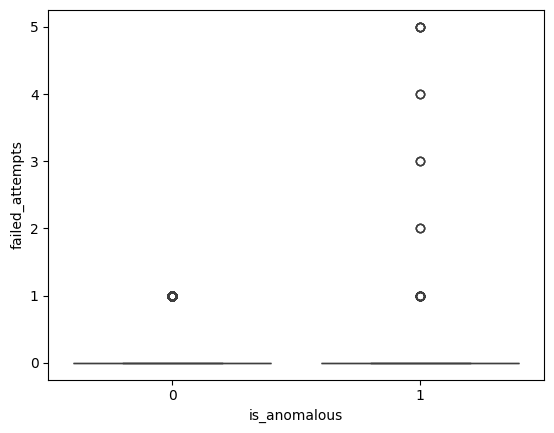

In [8]:

login=df[df.event_type=="login"]
display(login.groupby("is_anomalous")[["failed_attempts"]].mean())
sns.boxplot(data=login,x="is_anomalous",y="failed_attempts")
plt.show()


## Intermediate Task 3: Withdrawal Analysis

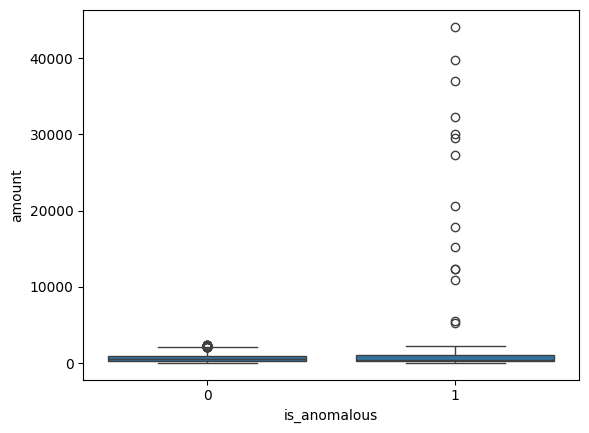

,count,mean,std,min,25%,50%,75%,max
is_anomalous,,,,,,,,
0,4839.0,667.625485,516.614693,50.00,241.4450,529.850,990.9350,2366.54
1,276.0,1807.461812,5776.978857,50.29,235.2575,467.265,1031.1825,44109.40


In [9]:

withdraw=df[df.event_type=="withdrawal"]
sns.boxplot(data=withdraw,x="is_anomalous",y="amount")
plt.show()
display(withdraw.groupby("is_anomalous")["amount"].describe())


## Intermediate Task 4: Click Rate Analysis

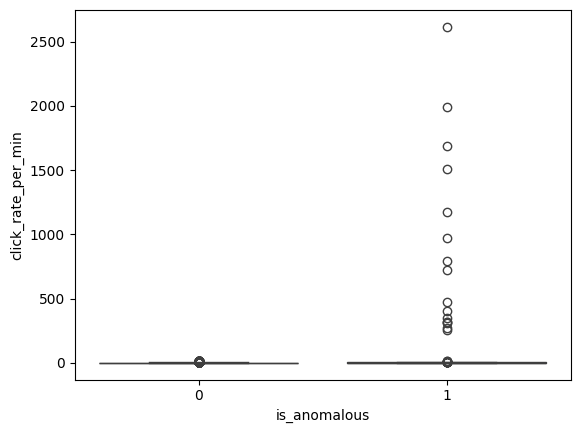

,count,mean,std,min,25%,50%,75%,max
is_anomalous,,,,,,,,
0,5719.0,1.850990,1.901665,0.08,0.69,1.290,2.21,15.0
1,302.0,48.620927,255.500133,0.10,0.71,1.335,2.36,2615.0


In [10]:

session=df[df.event_type=="session"]
sns.boxplot(data=session,x="is_anomalous",y="click_rate_per_min")
plt.show()
display(session.groupby("is_anomalous")["click_rate_per_min"].describe())



### Observations
- Anomalous sessions generally exhibit much higher click rates than normal sessions.
- Elevated click rates are consistent with automated or bot-like behaviour.



# Overall Summary

- The generated dataset contains realistic user activity across multiple event types.
- Normal and anomalous behaviours show noticeable differences in trading, withdrawals, and session activity.
- The injected anomaly patterns provide a strong foundation for feature engineering and anomaly detection in Week 4.
